In [1]:
#!/usr/bin/env python3 

In [29]:
# Importing the necessary modules 
import os 
import ollama
import cv2 
import random
import numpy as np 
import matplotlib.pyplot as plt 
from ultralytics import YOLO 
import tensorflow as tf 

In [3]:
# Loading the model 
model = YOLO("yolo11n-seg.pt") 

In [105]:
# Setting the path to the image 
imagePath = "image3.jpg" 

# Running the inference 
results = model.predict(source=imagePath, save=False, conf=0.25) 


image 1/1 /Users/mbonuchinedum/Documents/Projects/prismVision/notebooks/image3.jpg: 640x448 9 persons, 1 car, 91.7ms
Speed: 6.4ms preprocess, 91.7ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 448)


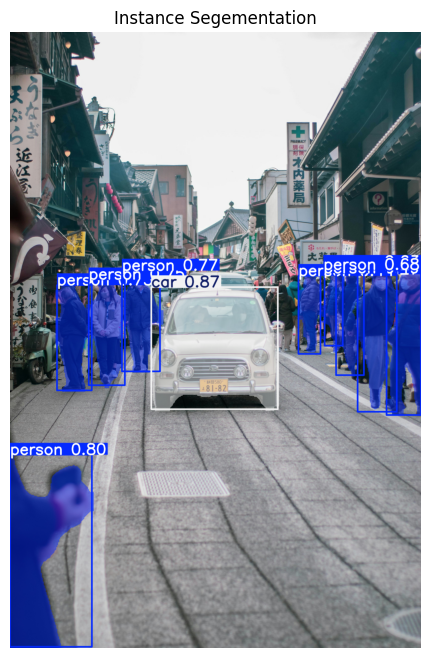

In [106]:
# Process and display with matplotlib 
for r in results: 
    # Plot the image 
    resBgr = r.plot() 

    # Convert BGR to RGB 
    resRgb = cv2.cvtColor(resBgr, cv2.COLOR_BGR2RGB) 

    # Display using matplotlib 
    plt.figure(figsize=(12, 8)) 
    plt.imshow(resRgb) 
    plt.axis("off") 
    plt.title("Instance Segementation") 
    plt.show() 

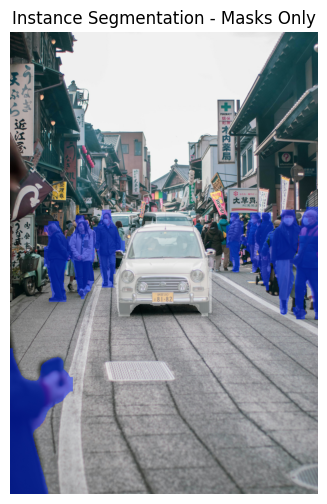

In [107]:
# Removing the bounding boxes 
# 4. Process and Display
for r in results:
    # Use boxes=False to hide the bounding boxes and labels
    # Use labels=False if you want to keep boxes but hide text (optional)
    res_bgr = r.plot(boxes=False) 
    
    # Convert BGR to RGB for Matplotlib
    res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB)
    
    # Display using Matplotlib
    plt.figure(figsize=(10, 6))
    plt.imshow(res_rgb)
    plt.axis("off")
    plt.title("Instance Segmentation - Masks Only")
    plt.show()

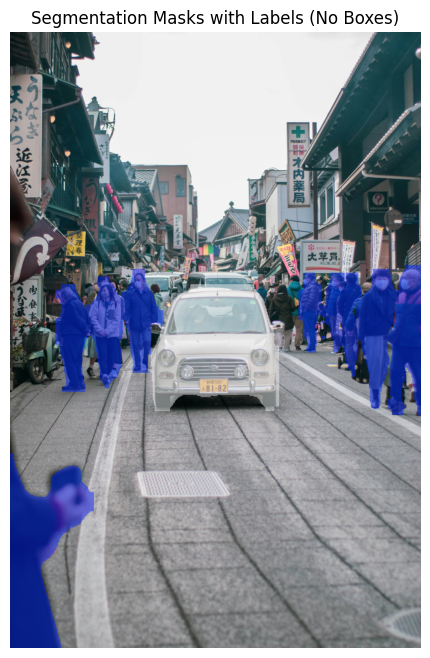

In [108]:
# 4. Visualization logic
for r in results:
    # boxes=False: Removes the rectangular border
    # labels=True: Keeps the text label (class name + confidence)
    # The label will typically hover near the top of the segmented region
    res_bgr = r.plot(boxes=False, labels=True)
    
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB)
    
    # Render in Jupyter
    plt.figure(figsize=(12, 8))
    plt.imshow(res_rgb)
    plt.axis("off")
    plt.title("Segmentation Masks with Labels (No Boxes)")
    plt.show()

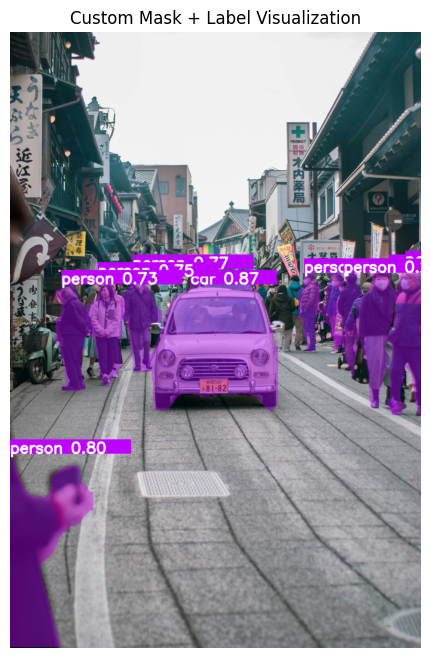

In [109]:
# 3. Create a copy of the original image to draw on
annotated_img = results[0].orig_img.copy()

# 4. Manual drawing loop
if results[0].masks is not None:
    for mask, box in zip(results[0].masks.xy, results[0].boxes):
        # --- A. Draw the Mask ---
        # Create a semi-transparent overlay for the mask
        overlay = annotated_img.copy()
        points = np.array(mask, dtype=np.int32)
        cv2.fillPoly(overlay, [points], color=(255, 0, 189))  # Green mask

        # 
        # color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        
        # Blend the overlay with the original (alpha=0.4 for transparency)
        cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

        # --- B. Draw the Label ---
        label = f"{model.names[int(box.cls)]} {float(box.conf):.2f}"
        
        # Find the top-most point of the mask to place the label
        x, y = points[np.argmin(points[:, 1])]
        
        # Draw text with a small background for readability
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 5, 5)
        cv2.rectangle(annotated_img, (x, y - th - 5), (x + tw, y), (255, 0, 189), -1)
        cv2.putText(annotated_img, label, (x, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 4, (255, 255, 255), 15, cv2.LINE_AA)

# 5. Display with Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Custom Mask + Label Visualization")
plt.show()

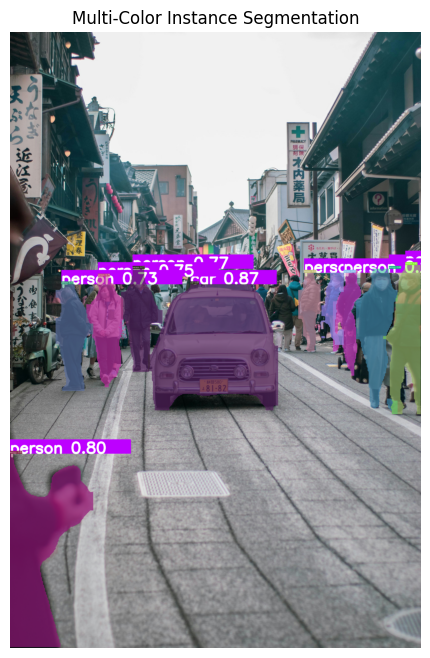

In [110]:
# 4. Draw each instance with a unique color
if results[0].masks is not None:
    # Iterate through masks, bounding boxes, and class IDs simultaneously
    for i, (mask, box) in enumerate(zip(results[0].masks.xy, results[0].boxes)):
        
        # Generate a unique color for this specific instance
        # We use a seed so the colors are consistent if you run it again
        random.seed(int(box.cls) + i) 
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        
        # --- A. Draw the Mask ---
        overlay = annotated_img.copy()
        points = np.array(mask, dtype=np.int32)
        cv2.fillPoly(overlay, [points], color=color)
        
        # Blend (Alpha = 0.5)
        cv2.addWeighted(overlay, 0.5, annotated_img, 0.5, 0, annotated_img)

        # --- B. Draw the Label ---
        label = f"{model.names[int(box.cls)]} {float(box.conf):.2f}"
        
        # Find highest point for label placement
        x, y = points[np.argmin(points[:, 1])]
        
        # Draw a small background rectangle for the text to make it readable
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated_img, (x, y - th - 10), (x + tw, y), color, -1)
        # White or black text depending on color brightness could be fancy, 
        # but white (255, 255, 255) usually works well:
        cv2.putText(annotated_img, label, (x, y - 7), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

# 5. Final Display
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Multi-Color Instance Segmentation")
plt.show()

car: 0.87
person: 0.80
person: 0.77
person: 0.75
person: 0.73
person: 0.68
person: 0.63
person: 0.49
person: 0.44
person: 0.27


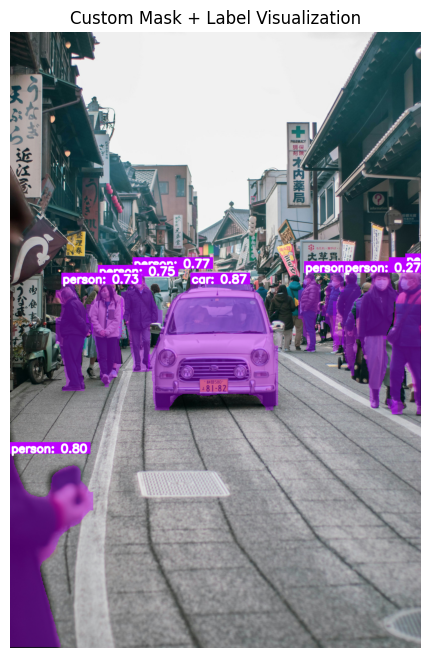

In [111]:
# 3. Create a copy of the original image to draw on
annotated_img = results[0].orig_img.copy()

padding_x = 10
padding_y = 10
font_scale = 3
thickness = 15  # Higher number = Bolder text
font = cv2.FONT_HERSHEY_SIMPLEX
bg_color = (255, 0, 189) # Ultralytics Purple (BGR)
text_color = (255, 255, 255) # White

# 4. Manual drawing loop
if results[0].masks is not None:
    for mask, box in zip(results[0].masks.xy, results[0].boxes):
        # --- A. Draw the Mask ---
        # Create a semi-transparent overlay for the mask
        overlay = annotated_img.copy()
        points = np.array(mask, dtype=np.int32)
        cv2.fillPoly(overlay, [points], color=(255, 0, 189))  # Green mask

        # 
        # color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        
        # Blend the overlay with the original (alpha=0.4 for transparency)
        cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

        # --- B. Draw the Label ---
        label = f"{model.names[int(box.cls)]}: {float(box.conf):.2f}"

        print(label) 
        
        # Find the top-most point of the mask to place the label
        x, y = points[np.argmin(points[:, 1])]
        
        # 1. Calculate text size
        (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        
        # 2. Draw background rectangle with padding
        # We subtract padding from y and add it to x/th to expand the box
        bg_rect_start = (x, y - th - (padding_y * 2))
        bg_rect_end = (x + tw + (padding_x * 2), y)
        cv2.rectangle(annotated_img, bg_rect_start, bg_rect_end, bg_color, -1)
        
        # 3. Draw the BOLD text
        # We add padding_x to the x-coordinate so the text isn't touching the left edge
        # We subtract padding_y from the y-coordinate to center it vertically
        text_position = (x + padding_x, y - padding_y)
        cv2.putText(annotated_img, label, text_position, 
                    font, font_scale, text_color, thickness, cv2.LINE_AA)

# 5. Display with Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Custom Mask + Label Visualization")
plt.show()